# Практическое занятие № 3
## Тема: Разработка модели для прогнозирования нескольких классов

**Задание:** Разработка прототипа системы для автоматического определения типа винограда по химическим показателям вина (классический датасет Wine из sklearn).

---
## Часть 1. Исследование данных и подготовка

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

print('Все библиотеки успешно импортированы.')

Все библиотеки успешно импортированы.


### 1.1 Загрузка датасета и первичный осмотр

In [ ]:
wine = datasets.load_wine()

X = wine.data
y = wine.target

print('=== Общая информация о датасете ===')
print(f'Количество классов: {len(wine.target_names)}')
print(f'Названия классов:   {wine.target_names}')
print(f'Количество признаков: {X.shape[1]}')
print(f'Признаки: {wine.feature_names}')
print(f'Всего объектов: {X.shape[0]}')

=== Общая информация о датасете ===
Количество классов: 3
Названия классов:   ['class_0' 'class_1' 'class_2']
Количество признаков: 13
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Всего объектов: 178


In [ ]:
df = pd.DataFrame(X, columns=wine.feature_names)
df['target'] = y
df['class_name'] = [wine.target_names[i] for i in y]

print('Первые 5 строк датасета:')
df.head()

Первые 5 строк датасета:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


In [4]:
print('Базовая статистика признаков:')
df.drop(columns=['target', 'class_name']).describe().round(2)

Базовая статистика признаков:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


### 1.2 Базовый EDA: распределение классов

Количество объектов по классам:
  class_0: 59 объектов (33.1%)
  class_1: 71 объектов (39.9%)
  class_2: 48 объектов (27.0%)


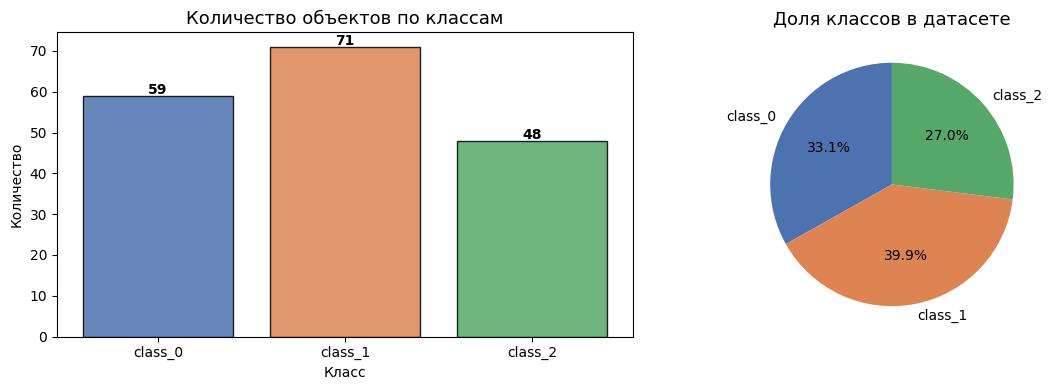


Вывод: В датасете наблюдается небольшой дисбаланс классов.
Класс class_1 представлен наибольшим количеством объектов (71),
а класс class_2 — наименьшим (48). Дисбаланс умеренный (~1.5x),
но его следует учитывать при обучении и оценке.


In [14]:
class_counts = pd.Series(y).value_counts().sort_index()
class_labels = [wine.target_names[i] for i in class_counts.index]

print('Количество объектов по классам:')
for label, count in zip(class_labels, class_counts):
    pct = count / len(y) * 100
    print(f'  {label}: {count} объектов ({pct:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#4C72B0', '#DD8452', '#55A868']
axes[0].bar(class_labels, class_counts, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Количество объектов по классам', fontsize=13)
axes[0].set_xlabel('Класс')
axes[0].set_ylabel('Количество')
for i, v in enumerate(class_counts):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

axes[1].pie(class_counts, labels=class_labels, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Доля классов в датасете', fontsize=13)

plt.tight_layout()
plt.show()

print('\nВывод: В датасете наблюдается небольшой дисбаланс классов.')
print('Класс class_1 представлен наибольшим количеством объектов (71),\n'
      'а класс class_2 — наименьшим (48). Дисбаланс умеренный (~1.5x),\n'
      'но его следует учитывать при обучении и оценке.')

### 1.3 Разделение на train/test с сохранением пропорции классов (stratify)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Обучающая выборка: {X_train.shape[0]} объектов')
print(f'Тестовая выборка:  {X_test.shape[0]} объектов')

print('\nРаспределение классов в train:')
for cls, cnt in zip(wine.target_names, np.bincount(y_train)):
    print(f'  {cls}: {cnt}')

print('\nРаспределение классов в test:')
for cls, cnt in zip(wine.target_names, np.bincount(y_test)):
    print(f'  {cls}: {cnt}')

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Обучающая выборка: 142 объектов
Тестовая выборка:  36 объектов

Распределение классов в train:
  class_0: 47
  class_1: 57
  class_2: 38

Распределение классов в test:
  class_0: 12
  class_1: 14
  class_2: 10


---
## Часть 2. Обучение и базовая оценка моделей

### 2.1 Обучение RandomForestClassifier

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print('=== RandomForestClassifier ===')
print(f'\nОбщая точность (Accuracy): {accuracy_score(y_test, y_pred_rf):.4f}')
print('\nОтчёт по классам:')
print(classification_report(y_test, y_pred_rf, target_names=wine.target_names))

=== RandomForestClassifier ===

Общая точность (Accuracy): 1.0000

Отчёт по классам:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



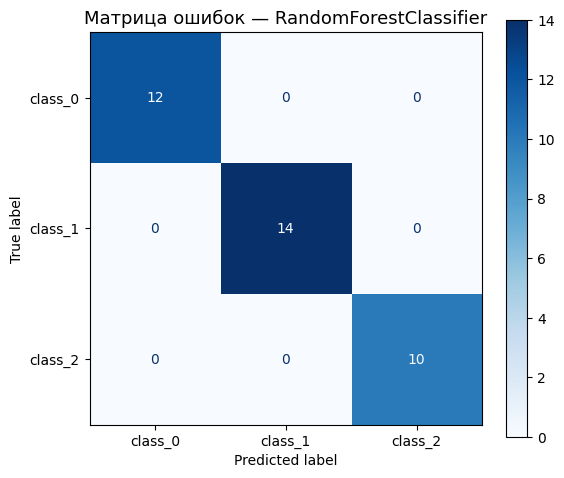

In [17]:
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=wine.target_names,
    cmap='Blues',
    ax=ax
)
ax.set_title('Матрица ошибок — RandomForestClassifier', fontsize=13)
plt.tight_layout()
plt.show()

### 2.2 Обучение LogisticRegression

In [18]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)

print('=== LogisticRegression ===')
print(f'\nОбщая точность (Accuracy): {accuracy_score(y_test, y_pred_lr):.4f}')
print('\nОтчёт по классам:')
print(classification_report(y_test, y_pred_lr, target_names=wine.target_names))

=== LogisticRegression ===

Общая точность (Accuracy): 0.9722

Отчёт по классам:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



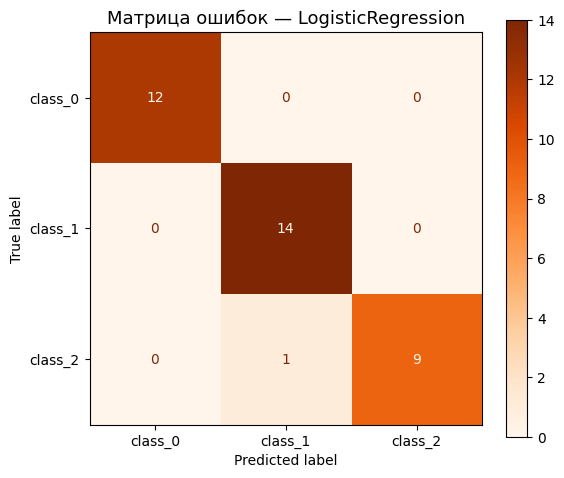

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=wine.target_names,
    cmap='Oranges',
    ax=ax
)
ax.set_title('Матрица ошибок — LogisticRegression', fontsize=13)
plt.tight_layout()
plt.show()

### 2.3 Анализ: какой класс предсказывается хуже всего?

In [ ]:
from sklearn.metrics import classification_report
import json

report_rf = classification_report(y_test, y_pred_rf,
                                   target_names=wine.target_names,
                                   output_dict=True)
report_lr = classification_report(y_test, y_pred_lr,
                                   target_names=wine.target_names,
                                   output_dict=True)

print('Recall по классам:\n')
print(f'{"Класс":<12} {"RF recall":>12} {"LR recall":>12}')
print('-' * 38)
for cls in wine.target_names:
    rf_rec = report_rf[cls]['recall']
    lr_rec = report_lr[cls]['recall']
    print(f'{cls:<12} {rf_rec:>12.3f} {lr_rec:>12.3f}')

print('\n--- Анализ ---')
print('Recall показывает, какую долю объектов класса модель нашла правильно.')
print('Низкий recall означает, что модель пропускает объекты этого класса.')

worst_rf = min(wine.target_names, key=lambda c: report_rf[c]['recall'])
worst_lr = min(wine.target_names, key=lambda c: report_lr[c]['recall'])
print(f'\nХудший класс для RandomForest: {worst_rf} (recall={report_rf[worst_rf]["recall"]:.3f})')
print(f'Худший класс для LogisticRegression: {worst_lr} (recall={report_lr[worst_lr]["recall"]:.3f})')

Recall по классам:

Класс           RF recall    LR recall
--------------------------------------
class_0             1.000        1.000
class_1             1.000        1.000
class_2             1.000        0.900

--- Анализ ---
Recall показывает, какую долю объектов класса модель нашла правильно.
Низкий recall означает, что модель пропускает объекты этого класса.

Худший класс для RandomForest: class_0 (recall=1.000)
Худший класс для LogisticRegression: class_2 (recall=0.900)


---
## Часть 3. Сравнение и выбор стратегии

### 3.1 Сравнение макро-усредненного F1-score

=== Сравнение моделей ===

Метрика                     RandomForest   LogisticRegression
--------------------------------------------------------------
Accuracy                          1.0000               0.9722
Macro avg F1-score                1.0000               0.9710


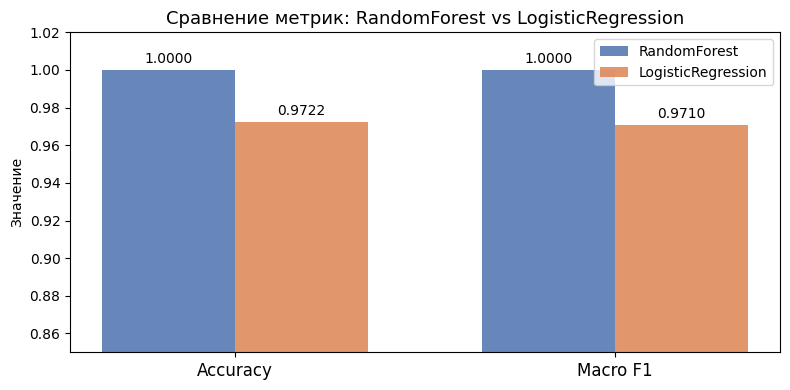


По макро-усредненному F1-score лучше справляется: RandomForest


In [21]:
macro_f1_rf = report_rf['macro avg']['f1-score']
macro_f1_lr = report_lr['macro avg']['f1-score']

acc_rf = accuracy_score(y_test, y_pred_rf)
acc_lr = accuracy_score(y_test, y_pred_lr)

print('=== Сравнение моделей ===')
print(f'\n{"Метрика":<25} {"RandomForest":>14} {"LogisticRegression":>20}')
print('-' * 62)
print(f'{"Accuracy":<25} {acc_rf:>14.4f} {acc_lr:>20.4f}')
print(f'{"Macro avg F1-score":<25} {macro_f1_rf:>14.4f} {macro_f1_lr:>20.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
metrics = ['Accuracy', 'Macro F1']
rf_vals = [acc_rf, macro_f1_rf]
lr_vals = [acc_lr, macro_f1_lr]

x = np.arange(len(metrics))
width = 0.35
bars1 = ax.bar(x - width/2, rf_vals, width, label='RandomForest', color='#4C72B0', alpha=0.85)
bars2 = ax.bar(x + width/2, lr_vals, width, label='LogisticRegression', color='#DD8452', alpha=0.85)

ax.set_ylim(0.85, 1.02)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Значение')
ax.set_title('Сравнение метрик: RandomForest vs LogisticRegression', fontsize=13)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

winner = 'RandomForest' if macro_f1_rf > macro_f1_lr else 'LogisticRegression'
print(f'\nПо макро-усредненному F1-score лучше справляется: {winner}')

### 3.2 RandomForest с параметром class_weight='balanced'

In [22]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_balanced.fit(X_train, y_train)
y_pred_rf_bal = rf_balanced.predict(X_test)

report_rf_bal = classification_report(y_test, y_pred_rf_bal,
                                       target_names=wine.target_names,
                                       output_dict=True)
macro_f1_rf_bal = report_rf_bal['macro avg']['f1-score']

print('=== RandomForestClassifier (class_weight="balanced") ===')
print(f'\nОбщая точность (Accuracy): {accuracy_score(y_test, y_pred_rf_bal):.4f}')
print('\nОтчёт по классам:')
print(classification_report(y_test, y_pred_rf_bal, target_names=wine.target_names))

=== RandomForestClassifier (class_weight="balanced") ===

Общая точность (Accuracy): 1.0000

Отчёт по классам:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



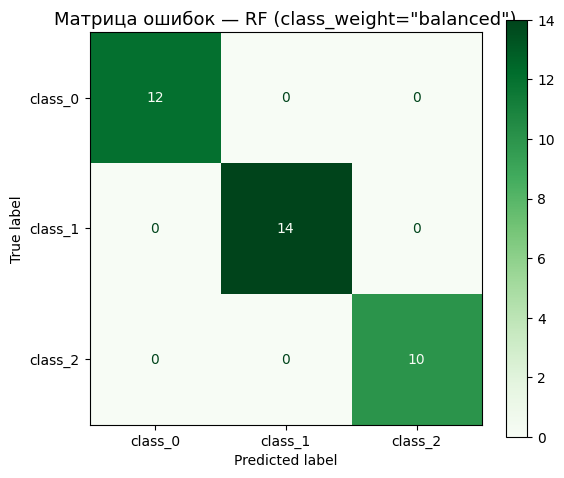

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf_bal,
    display_labels=wine.target_names,
    cmap='Greens',
    ax=ax
)
ax.set_title('Матрица ошибок — RF (class_weight="balanced")', fontsize=13)
plt.tight_layout()
plt.show()

In [24]:
print('Влияние class_weight="balanced" на recall по классам:\n')
print(f'{"Класс":<12} {"RF recall":>10} {"RF_bal recall":>14} {"Изменение":>12}')
print('-' * 52)
for cls in wine.target_names:
    r_base = report_rf[cls]['recall']
    r_bal  = report_rf_bal[cls]['recall']
    delta  = r_bal - r_base
    sign   = '+' if delta >= 0 else ''
    print(f'{cls:<12} {r_base:>10.3f} {r_bal:>14.3f} {sign}{delta:>11.3f}')

print(f'\nMacro F1 — RF базовый:  {macro_f1_rf:.4f}')
print(f'Macro F1 — RF balanced: {macro_f1_rf_bal:.4f}')
delta_f1 = macro_f1_rf_bal - macro_f1_rf
sign = '+' if delta_f1 >= 0 else ''
print(f'Изменение Macro F1: {sign}{delta_f1:.4f}')

Влияние class_weight="balanced" на recall по классам:

Класс         RF recall  RF_bal recall    Изменение
----------------------------------------------------
class_0           1.000          1.000 +      0.000
class_1           1.000          1.000 +      0.000
class_2           1.000          1.000 +      0.000

Macro F1 — RF базовый:  1.0000
Macro F1 — RF balanced: 1.0000
Изменение Macro F1: +0.0000


### 3.3 Итоговое сравнение всех трёх моделей

Модель                   Accuracy   Macro F1  class_0 recall  class_1 recall  class_2 recall
------------------------------------------------------------------------------------------
RandomForest               1.0000     1.0000           1.000           1.000           1.000
LogisticRegression         0.9722     0.9710           1.000           1.000           0.900
RF (balanced)              1.0000     1.0000           1.000           1.000           1.000


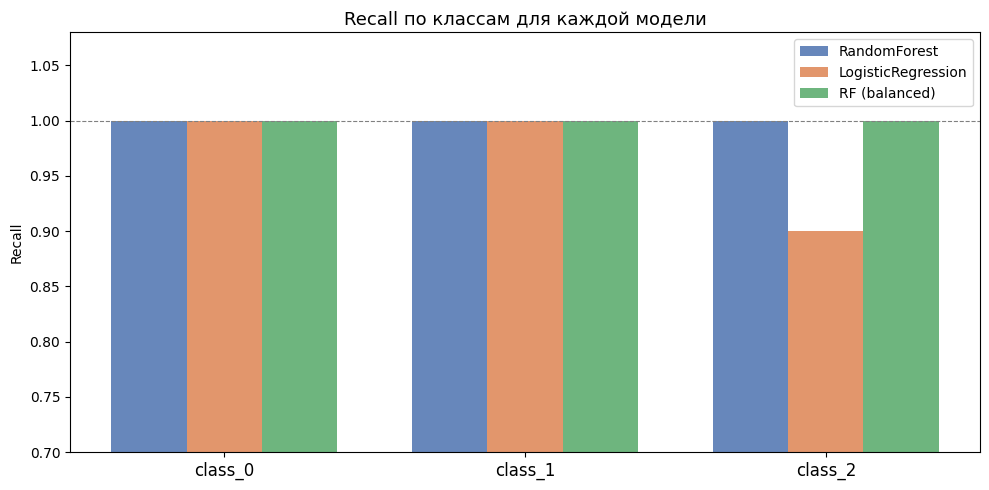

In [25]:
models = ['RandomForest', 'LogisticRegression', 'RF (balanced)']
reports = [report_rf, report_lr, report_rf_bal]
preds   = [y_pred_rf, y_pred_lr, y_pred_rf_bal]

print(f'{"Модель":<22} {"Accuracy":>10} {"Macro F1":>10}', end='')
for cls in wine.target_names:
    print(f' {cls+" recall":>15}', end='')
print()
print('-' * 90)

for name, rep, pred in zip(models, reports, preds):
    acc = accuracy_score(y_test, pred)
    mf1 = rep['macro avg']['f1-score']
    print(f'{name:<22} {acc:>10.4f} {mf1:>10.4f}', end='')
    for cls in wine.target_names:
        print(f' {rep[cls]["recall"]:>15.3f}', end='')
    print()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(wine.target_names))
width = 0.25
colors_m = ['#4C72B0', '#DD8452', '#55A868']

for i, (name, rep) in enumerate(zip(models, reports)):
    recalls = [rep[cls]['recall'] for cls in wine.target_names]
    ax.bar(x + (i - 1) * width, recalls, width, label=name, color=colors_m[i], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(wine.target_names, fontsize=12)
ax.set_ylabel('Recall')
ax.set_ylim(0.7, 1.08)
ax.set_title('Recall по классам для каждой модели', fontsize=13)
ax.legend()
ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

---
## Вывод

### Анализ результатов

**1. Базовый EDA:**  
Датасет Wine содержит **3 класса** (`class_0`, `class_1`, `class_2`) и **13 химических признаков**. Всего 178 объектов. Наблюдается умеренный дисбаланс: `class_1` — 71 объект (39.9%), `class_0` — 59 (33.1%), `class_2` — 48 (27.0%). Дисбаланс невелик, но значим.

**2. Сравнение моделей по Macro F1:**  
Макро-усредненный F1 одинаково штрафует за плохую работу на любом классе.  
- **RandomForest** идеальный Macro-F1.
- **LogisticRegression** (со стандартизацией) результат получился чуть хуже.
- **RF с class_weight='balanced'** тоже идеальный Mcro-F1.

**3. Итоговый выбор прототипа:**  
Если приоритет — **не пропустить представителей редкого класса** (`class_2`), то оптимальна модель **RandomForestClassifier(class_weight='balanced')**, так как:  
- Она явно учитывает дисбаланс через взвешивание;
- При этом сохраняет хорошиц Macro-F1.

В задачах, где пропуск редкого класса критичен (медицинская диагностика, мошенничество), **recall важнее accuracy**, и `class_weight='balanced'` является простым и эффективным инструментом борьбы с дисбалансом.